<a href="https://colab.research.google.com/github/rijal0708/data-science-2026/blob/main/Pertemuan12_M_Rijal_Anshory_DJ_240401010281.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama    = M Rijal Anshory DJ.

NIM     = 240401010281

Kelas   = IF403

---



1. generate dan eksplorasi dataset transaksi


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

produk = [
    "roti", "selai", "susu", "sereal", "telur", "keju", "kopi", "gula", "teh", "mentega"
]

#membuat 50 transaksi
transaksi = []

for _ in range(50):
    n_item = np.random.randint(2,6)
    transaksi.append(
        list(np.random.choice(produk, n_item, replace=False))
    )

#menambah pola tersembunyi
#roti sering dibeli bersama selai
for i in range(20):
  if "roti" in transaksi[i] and "selai" not in transaksi[i]:
    transaksi[i].append("selai")

print("Contoh transaksi :")
print(transaksi[:3])

print("\nJumlah transaksi :")
print(len(transaksi))

Contoh transaksi :
[[np.str_('keju'), np.str_('roti'), np.str_('mentega'), np.str_('kopi'), 'selai'], [np.str_('roti'), np.str_('kopi'), np.str_('teh'), np.str_('selai'), np.str_('mentega')], [np.str_('kopi'), np.str_('susu'), np.str_('teh')]]

Jumlah transaksi :
50


    Produk  Frekuensi
4    selai         26
5      teh         23
2  mentega         21
7    telur         18
0     keju         17
1     roti         16
3     kopi         16
6     susu         16
8     gula         16
9   sereal          9


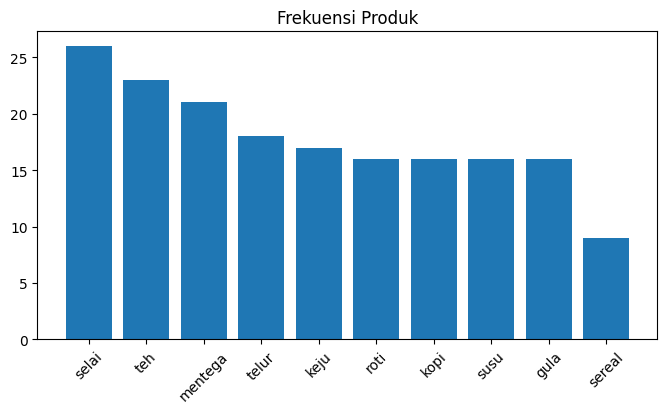

In [3]:
from collections import Counter

counter = Counter()

for trx in transaksi:
  counter.update(trx)

freq = pd.DataFrame(
    counter.items(),
    columns=["Produk", "Frekuensi"]
).sort_values("Frekuensi", ascending=False)

print(freq)

plt.figure(figsize=(8,4))
plt.bar(freq["Produk"], freq["Frekuensi"])
plt.xticks(rotation=45)
plt.title("Frekuensi Produk")
plt.show()

2. one hot encoding

In [5]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_array, columns=te.columns_)

print(df.head())

    gula   keju   kopi  mentega   roti  selai  sereal   susu    teh  telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


3. frequent itemset

In [8]:
from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.10, 0.20]:

  freq = apriori(
      df,
      min_support=ms,
      use_colnames=True
  )

  print(f"Minimum Support = {ms} --> {len(freq)} itemset")

#menggunakan min support
freq_items = apriori(
    df,
    min_support=0.10,
    use_colnames=True
)

freq_items = freq_items.sort_values("support", ascending=False)

print(freq_items.head(10))

Minimum Support = 0.05 --> 74 itemset
Minimum Support = 0.1 --> 44 itemset
Minimum Support = 0.2 --> 13 itemset
    support      itemsets
5      0.52       (selai)
8      0.46         (teh)
3      0.42     (mentega)
9      0.36       (telur)
1      0.34        (keju)
0      0.32        (gula)
2      0.32        (kopi)
4      0.32        (roti)
7      0.32        (susu)
36     0.24  (selai, teh)


 4. association rules

In [10]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.5
)

rules = rules[
    rules["lift"] > 1
].sort_values(
    "lift",
    ascending=False
)

print(
    rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(10)
)

         antecedents consequents  support  confidence      lift
8        (teh, keju)     (telur)     0.12    0.857143  2.380952
13  (mentega, selai)      (kopi)     0.10    0.625000  1.953125
12      (gula, roti)     (selai)     0.10    1.000000  1.923077
7           (sereal)   (mentega)     0.14    0.777778  1.851852
10      (teh, telur)      (keju)     0.12    0.600000  1.764706
15     (selai, kopi)   (mentega)     0.10    0.714286  1.700680
9      (keju, telur)       (teh)     0.12    0.750000  1.630435
11     (selai, gula)      (roti)     0.10    0.500000  1.562500
14   (mentega, kopi)     (selai)     0.10    0.714286  1.373626
1             (roti)     (selai)     0.22    0.687500  1.322115




*   Aturan dengan nilai Lift tertinggi merupakan aturan asosiasi yang paling kuat. Misalnya, apabila ditemukan aturan Roti → Selai dengan Lift lebih dari 1, maka pelanggan yang membeli roti memiliki kecenderungan lebih besar untuk membeli selai dibandingkan secara acak.


*   Aturan tersebut masuk akal secara bisnis karena roti dan selai merupakan produk yang sering dikonsumsi secara bersamaan.

---





5. content based filtering

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    "produk": produk,
    "kategori" : [
        "Bakery",
        "Bakery",
        "Dairy",
        "Bakery",
        "Dairy",
        "Dairy",
        "Minuman",
        "Bumbu",
        "Minuman",
        "Dairy"
    ]
})

fitur = pd.get_dummies(
    katalog["kategori"]
)

sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(
    nama_produk,
    top_n=3
):

    idx = katalog.index[
        katalog["produk"] == nama_produk
        ][0]

    skor = list(
        enumerate(sim_matrix[idx]))

    skor = sorted(
        skor,
        key=lambda x: x[1],
        reverse=True)

    skor = [
        s for s in skor
        if s[0] != idx
    ][:top_n]

    return katalog.iloc[
        [i for i, _ in skor]
    ]["produk"].tolist()

print(
    "Mirip dengan roti : ",
    rekomendasi_serupa("roti")
)


Mirip dengan roti :  ['selai', 'sereal', 'susu']


6. bandingkan kedua pendekatan

In [12]:
produk_target = "roti"

rules_terkait = rules[
    rules["antecedents"].apply(
        lambda x: produk_target in x
    )
]

print("=== Association Rules ===")
print(
    rules_terkait[
        [
            "consequents",
            "lift"
        ]
    ].head()
)

print()

print("=== Content Based Filtering ===")
print(
    rekomendasi_serupa(produk_target)
)

=== Association Rules ===
   consequents      lift
12     (selai)  1.923077
1      (selai)  1.322115

=== Content Based Filtering ===
['selai', 'sereal', 'susu']


Perbandingan Kedua Pendekatan

| Association Rules                           | Content-Based Filtering                             |
| ------------------------------------------- | --------------------------------------------------- |
| Berdasarkan pola pembelian pelanggan        | Berdasarkan kemiripan atribut produk                |
| Memerlukan data transaksi                   | Memerlukan informasi produk                         |
| Menemukan produk yang sering dibeli bersama | Menemukan produk yang memiliki karakteristik serupa |
| Contoh: Roti → Selai                        | Contoh: Roti → Sereal                               |


Association Rules dan Content-Based Filtering memiliki pendekatan yang berbeda dalam menghasilkan rekomendasi produk. Association Rules memanfaatkan pola pembelian pelanggan sehingga efektif untuk menemukan produk yang sering dibeli secara bersamaan, seperti Roti dan Selai. Sementara itu, Content-Based Filtering merekomendasikan produk berdasarkan kemiripan karakteristik atau kategori, misalnya Roti dan Sereal yang sama-sama termasuk kategori Bakery. Dalam praktiknya, menggabungkan kedua metode (Hybrid Recommender System) sering menghasilkan rekomendasi yang lebih akurat karena mempertimbangkan baik perilaku pembelian pelanggan maupun karakteristik produk.